# CSP7040-Assignment: Data Preprocessing, Visualization & ML Readiness
## Netflix Content Analysis 🎬

**Project Objective:** Apply data preprocessing and visualization techniques and understand how poor data quality impacts machine learning models and the ML lifecycle

### Assignment divided into five parts/tasks:
1.  **Data Understanding & Quality Issues:** Key data quality issues are identified and briefly explained for analysis readiness after the dataset has been loaded to examine shape, data types, and missing values.
2.  **Data Cleaning & Preprocessing:** To produce structured input that is ready for machine learning, missing values are handled with explanation, data types are corrected, categorical features are encoded, and numerical features are scaled.
3.  **Data Visualization:** To identify trends, class balance, and feature relationships important for model learning, distribution, categorical count, and numerical comparison plots were developed and analyzed.
4.  **ML Readiness Check:** Performance compared before and after preprocessing and model evaluation.
5.  **ML Lifecycle Reflection:** Explains ML stages affected by poor data quality, showing importance of data preprocessing for successful model training.

# PART 1: Data Understanding & Quality Issues

- Load the dataset and inspect the shape, data types, and missing values.
- Identify at least five data quality issues and explain them briefly.


### Step 1: Setup - Importing Libraries

As always, we begin by importing our essential data science toolset, including a new library for word clouds.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set a consistent style for our plots
sns.set_style('darkgrid')

### Step 2: Data Loading and Initial Inspection

We'll load the `netflix_titles.csv` dataset and perform a high-level overview.

In [2]:
netflix_df = pd.read_csv('/content/netflix_titles.csv')
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
netflix_df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [4]:
netflix_df.shape

(8807, 12)

- We have 8807 entries (titles) and 12 columns.

In [5]:
netflix_df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
netflix_df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


- Only `release_year` is the integer datatype. Rest of the columns are of object datatype.

In [7]:
netflix_df.isnull().sum().sort_values(ascending=False)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [8]:
# Get a concise summary of the dataframe
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**Interpretation:**
- **Key Problem:** The `date_added` column is of type `object` (a string), not a `datetime` object. We cannot perform time-based analysis until this is corrected.
- **Missing Values:** `director`, `cast`, `country`, `date_added`, `rating` and `duration` all have missing values. `director` has the most significant number of nulls.

In [9]:
netflix_df['cast'].unique()

array([nan,
       'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng',
       'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera',
       ...,
       'Jesse Eisenberg, Woody Harrelson, Emma Stone, Abigail Breslin, Amber Heard, Bill Murray, Derek Graf',
       'Tim Allen, Courteney Cox, Chevy Chase, Kate Mara, Ryan Newman, Michael Cassidy, Spencer Breslin, Rip Torn, Kevin Zegers',
       'Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanana, Manish Chaudhary, Meghna Malik, Malkeet Rauni, Anita Shabdish, Chittaranjan Tripathy'],
      dtype=object)

In [10]:
netflix_df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


**Five data quality issues:**
- High missing values in `director` → reduces usefulness for ML.
- `duration` stored as text → cannot be used numerically.
- `date_added` in string format → prevents time-based analysis.
- Multiple values inside single categorical columns `country`, `cast` → not ML-friendly.
- Imbalanced categorical distribution in `type` → Movies >> TV Shows.

# PART 2: Data Cleaning & Preprocessing

- Handle missing values with justification.
- Explain why a particular technique(dropping,filling with mean/median) was chosen and its
impact on data quality
- Convert data into correct formats (dates, duration).
- Encode categorical variables.
- Normalize or standardize numerical features.

### Step 1: Data Cleaning and Transformation

This step is critical for ensuring our analysis is accurate. We will handle missing values and correct data types.

#### **Theoretical Concept: Data Type Conversion & Handling Nulls**
Data often comes in non-ideal formats. Storing dates as strings, for example, prevents us from extracting components like the year or month, or from plotting data over time. Converting columns to their proper data types (`pd.to_datetime`, `.astype()`) is a fundamental preprocessing step.

For null values, we have several strategies:
1.  **Drop:** If only a very small percentage of rows have missing data, dropping them might be acceptable (`.dropna()`).
2.  **Fill/Impute:** Replace missing values with a placeholder (like "Unknown") or a statistical measure (like the mode for categorical data). This is useful when you don't want to lose the other information in those rows.

In [11]:
# 1. Handle missing values in 'director' and 'cast'
# Since these are text fields and many are missing, we'll fill them with 'Unknown'.
netflix_df['director'] = netflix_df['director'].fillna('Unknown')
netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')

In [12]:
# 2. Handle missing 'country'
# We'll fill with the mode, which is the most common country.
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] = netflix_df['country'].fillna(mode_country)

In [13]:
# 3. Drop the few rows with missing 'date_added', 'rating' and 'duration'
# Since the number is small (less than 0.2% of data), dropping them is a safe option.
netflix_df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

In [14]:
# 4. Convert 'date_added' to datetime objects
# Use format='mixed' to handle potential variations in date formats
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], format='mixed', dayfirst=False)

* **format='mixed':** This argument tells pandas to infer the date format automatically. This is helpful when the date strings in the column have different formats.

* **dayfirst=False:** This argument specifies that when the date format is ambiguous (e.g., 01/02/2023), it should be interpreted as month first (January 2nd) rather than day first (February 1st).

In [15]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [16]:
netflix_df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


In [17]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [18]:
mins = netflix_df[netflix_df['duration'].str.contains('min')]['duration'].str.extract(r'(\d+)').astype(int)
seasons = netflix_df[netflix_df['duration'].str.contains('Season')]['duration'].str.extract(r'(\d+)').astype(int)

print("Minutes range:", mins.min()[0], "to", mins.max()[0])
print("Seasons range:", seasons.min()[0], "to", seasons.max()[0])

Minutes range: 3 to 312
Seasons range: 1 to 17


The `duration` column contains two different units: minutes for movies and seasons for TV shows.

- 🎬 Movies → "min" → typically 3–312 mins

- 📺 TV Shows → "Seasons" → typically 1–17

To preserve semantic meaning, the column was split into `duration_minutes` and `duration_seasons`.
This prevents misleading numerical relationships and makes the dataset ML-ready.

In [19]:
# extract numeric value
netflix_df['duration_value'] = netflix_df['duration'].str.extract(r'(\d+)').astype(float)

In [20]:
# create two separate columns
netflix_df['duration_minutes'] = np.where(netflix_df['duration'].str.contains('min'),
                                  netflix_df['duration_value'],
                                  np.nan)

netflix_df['duration_seasons'] = np.where(netflix_df['duration'].str.contains('Season'),
                                  netflix_df['duration_value'],
                                  np.nan)

In [21]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,90.0,NaN
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,NaN,2.0


Because duration in minutes is not applicable to TV shows and seasons are not applicable to movies. Filling them would introduce incorrect information.

Alternatively, A single numeric duration column  `duration_value` was created by extracting the numerical values from the original duration feature. Although the units differ (minutes for movies and seasons for TV shows), this approach is suitable because the target variable is content type.

In [22]:
netflix_df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


 Encoding categorical features
 Movie → 0 and TV Show → 1

In [23]:
netflix_df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [24]:
netflix_df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [25]:
kids = ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G']
family = ['TV-G', 'PG', 'TV-PG']
teens = ['PG-13', 'TV-14']
adult = ['R', 'NC-17', 'TV-MA']

def maturity_group(x):
    if x in kids:
        return 'Kids'
    elif x in family:
        return 'Family'
    elif x in teens:
        return 'Teens'
    elif x in adult:
        return 'Adult'
    else:
        return 'Unrated'

netflix_df['maturity_level'] = netflix_df['rating'].apply(maturity_group)

In [26]:
netflix_df['maturity_level'].unique()

array(['Teens', 'Adult', 'Family', 'Kids', 'Unrated'], dtype=object)

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
netflix_df['type'] = le.fit_transform(netflix_df['type'])
netflix_df['maturity_level'] = LabelEncoder().fit_transform(netflix_df['maturity_level'])

In [28]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_minutes,duration_seasons,maturity_level
0,s1,0,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,90.0,NaN,3
1,s2,1,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,NaN,2.0,0


Label encoding was chosen to keep the feature space small and avoid unnecessary dimensionality for this basic classification task.

#### Standard Scaler for data standardization

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apply scaling to these columns
netflix_df[['release_year', 'duration_value']] = scaler.fit_transform(
    netflix_df[['release_year', 'duration_value']]
)

netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_minutes,duration_seasons,maturity_level
0,s1,0,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,0.659134,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0.395056,90.0,NaN,3
1,s2,1,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,0.772449,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",-1.337515,NaN,2.0,0


In [30]:
# 5. Create new features for year and month added
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month

In [31]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_minutes,duration_seasons,maturity_level,year_added,month_added
0,s1,0,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,0.659134,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0.395056,90.0,NaN,3,2021,9
1,s2,1,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,0.772449,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",-1.337515,NaN,2.0,0,2021,9


# PART 3: Data Visualization

- One distribution plot.
- One categorical count plot.
- One numerical comparison plot.
- Provide interpretation for each plot.

### Step 1: Exploratory Data Analysis & Visualization

#### 1.1 What is the distribution of content type?

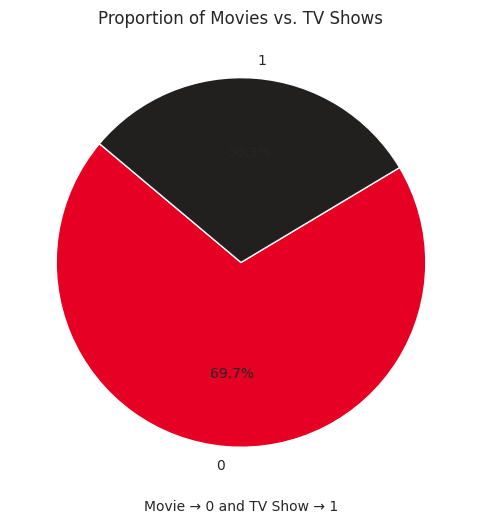

In [32]:
plt.figure(figsize=(8, 6))
type_counts = netflix_df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['#e60023', '#221f1f'])
plt.title('Proportion of Movies vs. TV Shows')
plt.xlabel('Movie → 0 and TV Show → 1')
plt.show()

**Insight:** The Netflix library is dominated by Movies, which make up roughly 64.2% of the content in this dataset.

#### 1.2 How has content been added over time?

<Figure size 1400x800 with 0 Axes>

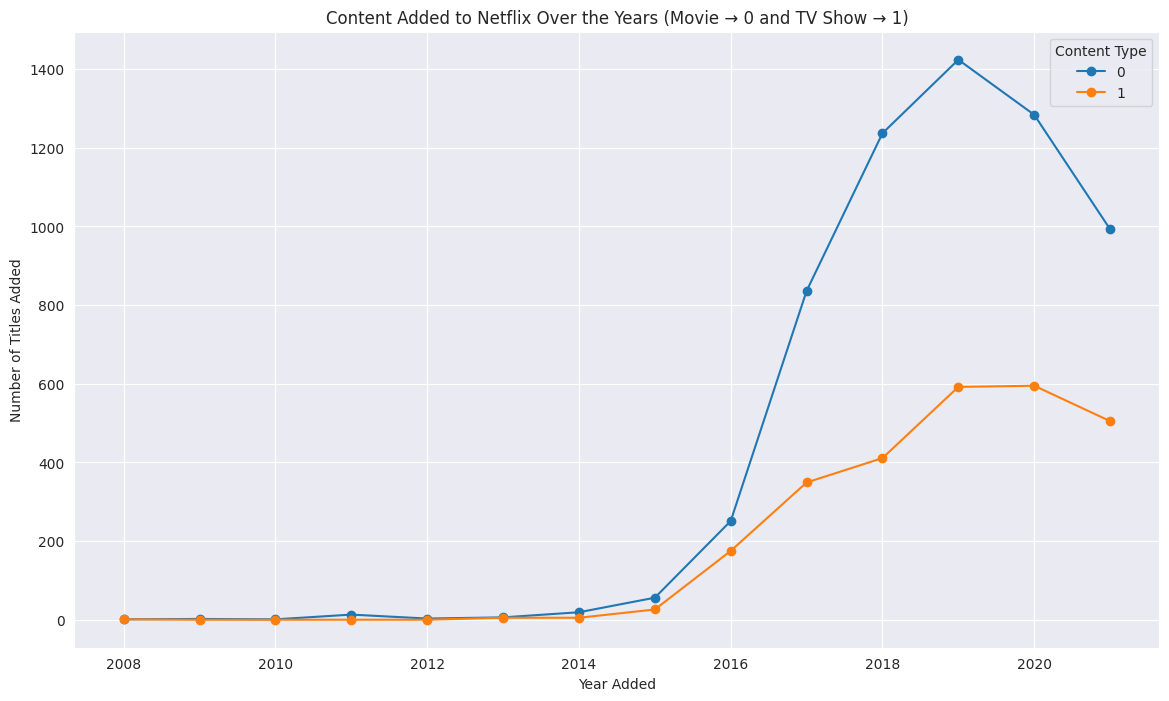

In [33]:
# Group data by year and content type
content_over_time = netflix_df.groupby(['year_added', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(14, 8))
content_over_time.plot(kind='line', marker='o', figsize=(14, 8))
plt.title('Content Added to Netflix Over the Years (Movie → 0 and TV Show → 1)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

**Insight:** By separating movies and TV shows, we can see that while both grew significantly, the addition of movies accelerated much more dramatically, peaking in 2019. The growth in TV shows has been more steady. There appears to be a slight slowdown in content additions in 2020 and 2021, which could be due to the COVID-19 pandemic affecting productions or the dataset being incomplete for the latest year.

#### 1.3 What are the most popular genres?

#### **Theoretical Concept: Handling Multi-Value Text Columns**
The `listed_in` column contains strings with multiple genres separated by commas (e.g., "Dramas, International Movies"). To analyze each genre individually, we need to transform the data. A common technique is to:
1.  **Split** the string in each row into a list of genres.
2.  **Explode** the DataFrame so that each genre in the list gets its own row, duplicating the other information for that title.
This allows us to perform a `value_counts()` on the genres.

In [34]:
# Split the 'listed_in' column and explode it
genres = netflix_df.assign(genre=netflix_df['listed_in'].str.split(', ')).explode('genre')

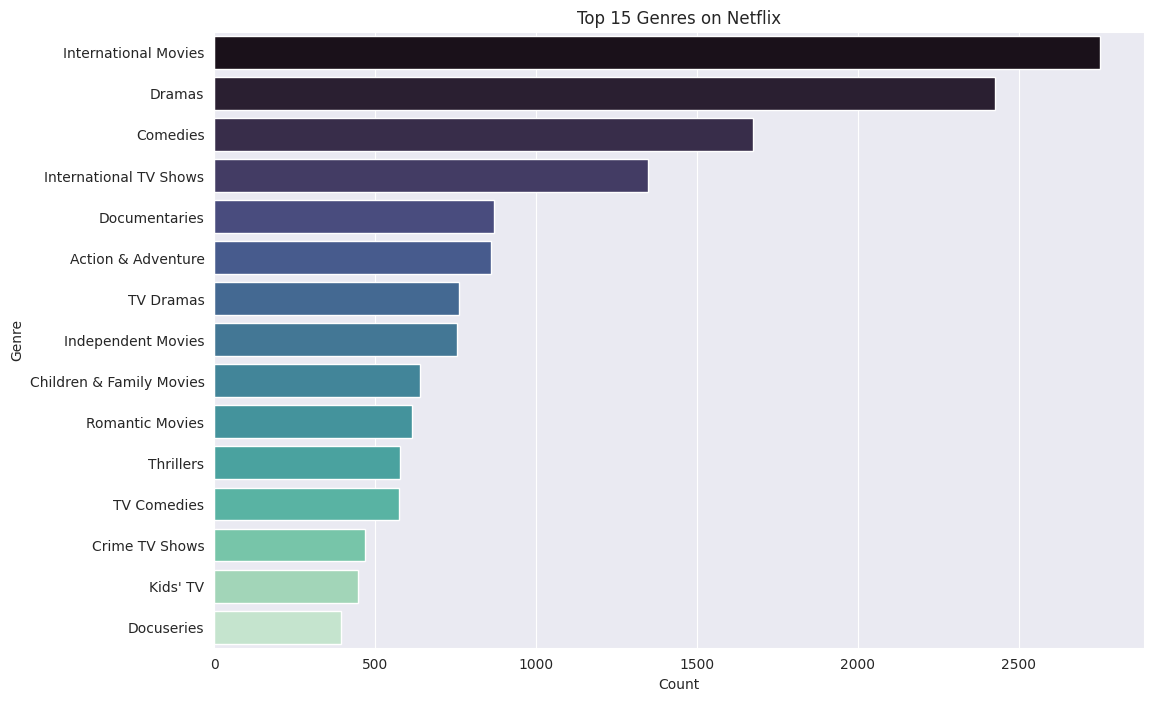

In [35]:
# Get the top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts().reset_index()
top_genres_counts.columns = ['genre', 'count'] # Rename columns for clarity

# Select only the top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(y='genre', x='count', data=top_genres_counts_plot, palette='mako', hue='genre', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

**Insight:** "International Movies" is the most common genre tag, highlighting Netflix's global content strategy. This is followed by Dramas, Comedies, and Action & Adventure.

#### 1.4 What is the distribution of content duration?

In [36]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_minutes,duration_seasons,maturity_level,year_added,month_added
0,s1,0,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,0.659134,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0.395056,90.0,NaN,3,2021,9
1,s2,1,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,0.772449,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",-1.337515,NaN,2.0,0,2021,9


In [37]:
# Separate movies and TV shows
movies_df = netflix_df[netflix_df['type'] == 0].copy()
tv_shows_df = netflix_df[netflix_df['type'] == 1].copy()

In [38]:
# movies_df.head()

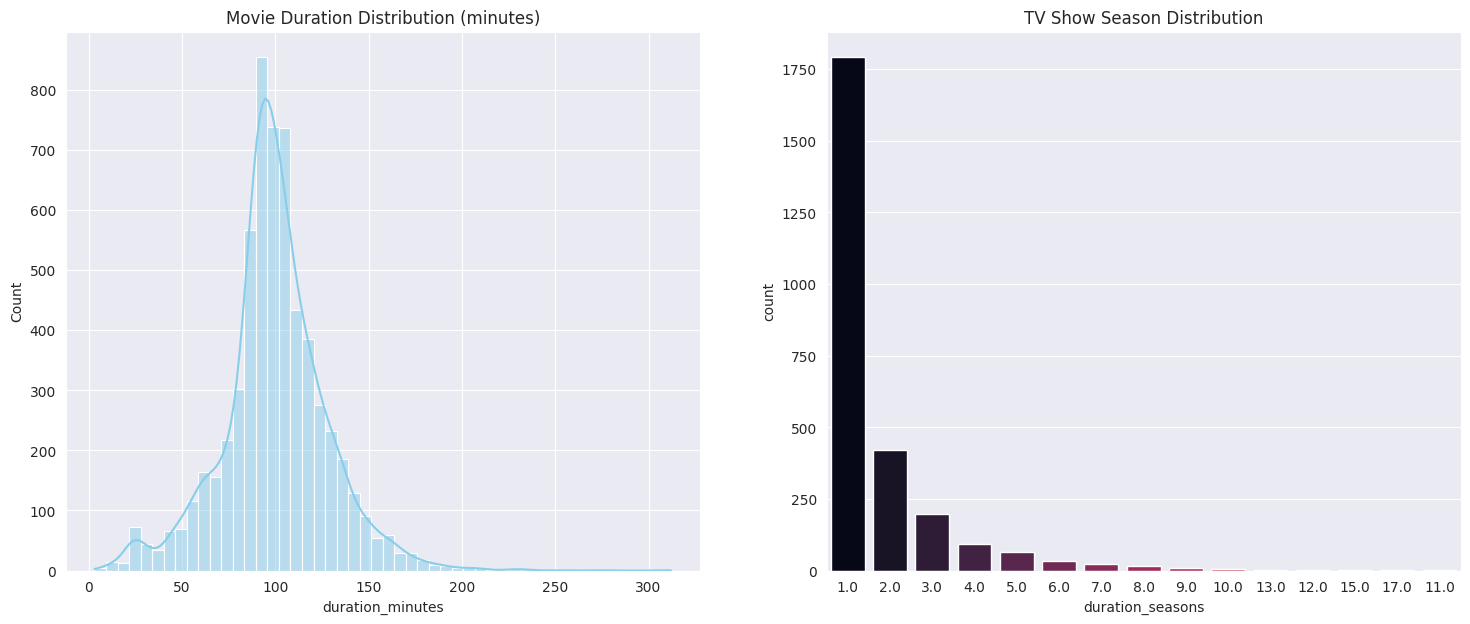

In [39]:
# Plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Movie Duration Distribution
sns.histplot(ax=axes[0], data=netflix_df, x='duration_minutes', bins=50, kde=True, color='skyblue').set_title('Movie Duration Distribution (minutes)')

# TV Show Season Distribution
sns.countplot(ax=axes[1], x='duration_seasons', data=netflix_df, palette='rocket', order=tv_shows_df['duration_seasons'].value_counts().index, hue='duration_seasons', legend=False).set_title('TV Show Season Distribution')

plt.show()

**Insight:**
- The majority of movies on Netflix are between 80 and 120 minutes long, which is standard for feature films.
- The vast majority of TV shows on Netflix are short-lived, with most having only 1 season. This could reflect a strategy of producing many pilots and only renewing the most successful ones, or a focus on limited series.

#### 1.5 Where does the content come from? (Geographical Analysis)

In [40]:
# Handle the multi-country listings similar to genres
countries = netflix_df.assign(country=netflix_df['country'].str.split(', ')).explode('country')

In [41]:
# Get the top 15 countries and their counts
top_countries_counts = countries['country'].value_counts().reset_index()
top_countries_counts.columns = ['country', 'count'] # Rename columns for clarity

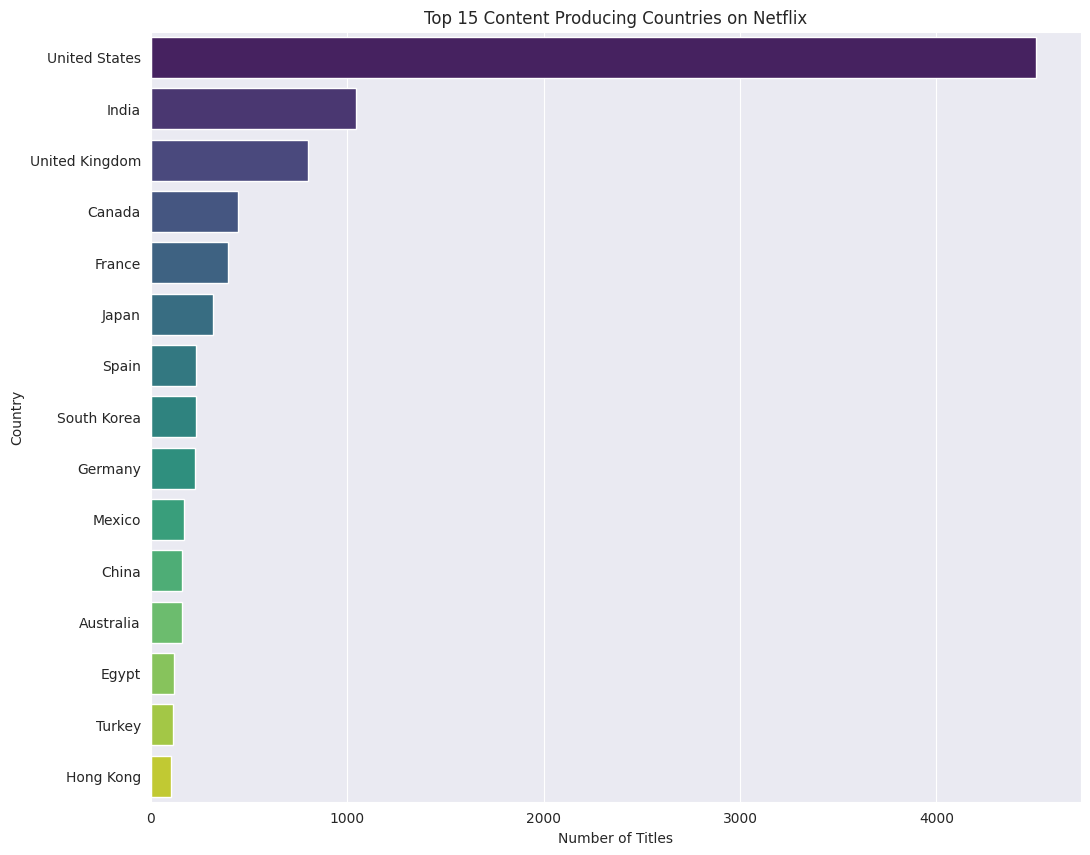

In [42]:
# Select only the top 15 for plotting
top_countries_counts_plot = top_countries_counts.head(15)

plt.figure(figsize=(12, 10))
sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='viridis', hue='country', legend=False)
plt.title('Top 15 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

**Insight:** The United States is by far the largest producer of content available on Netflix. However, India is a very strong second, which explains why so many of the top actors were from India. The UK, Japan, and South Korea also represent major content markets for the platform, emphasizing its global nature.

In [43]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_minutes,duration_seasons,maturity_level,year_added,month_added
0,s1,0,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,0.659134,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0.395056,90.0,NaN,3,2021,9
1,s2,1,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,0.772449,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",-1.337515,NaN,2.0,0,2021,9


#### 1.6 What are the maturity ratings of the content?

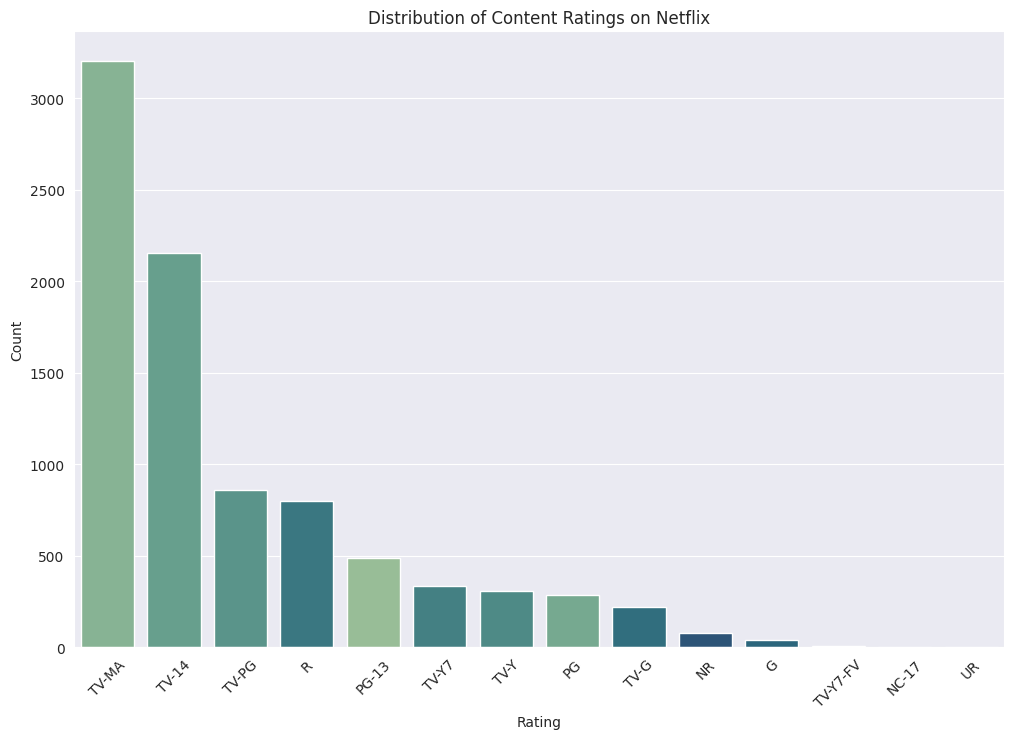

In [44]:
plt.figure(figsize=(12, 8))
sns.countplot(x='rating', data=netflix_df, order=netflix_df['rating'].value_counts().index, palette='crest', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight:** A large portion of Netflix's content is aimed at mature audiences, with `TV-MA` (Mature Audience) and `TV-14` (Parents Strongly Cautioned) being the two most common ratings. This suggests a focus on adult viewers over content for children (`TV-G`, `TV-Y`).

### Step 2: Feature Engineering - Content Freshness
Let's create a new feature to analyze how old content is when it gets added to Netflix. This can tell us about their acquisition strategy (buying old classics vs. releasing new originals).

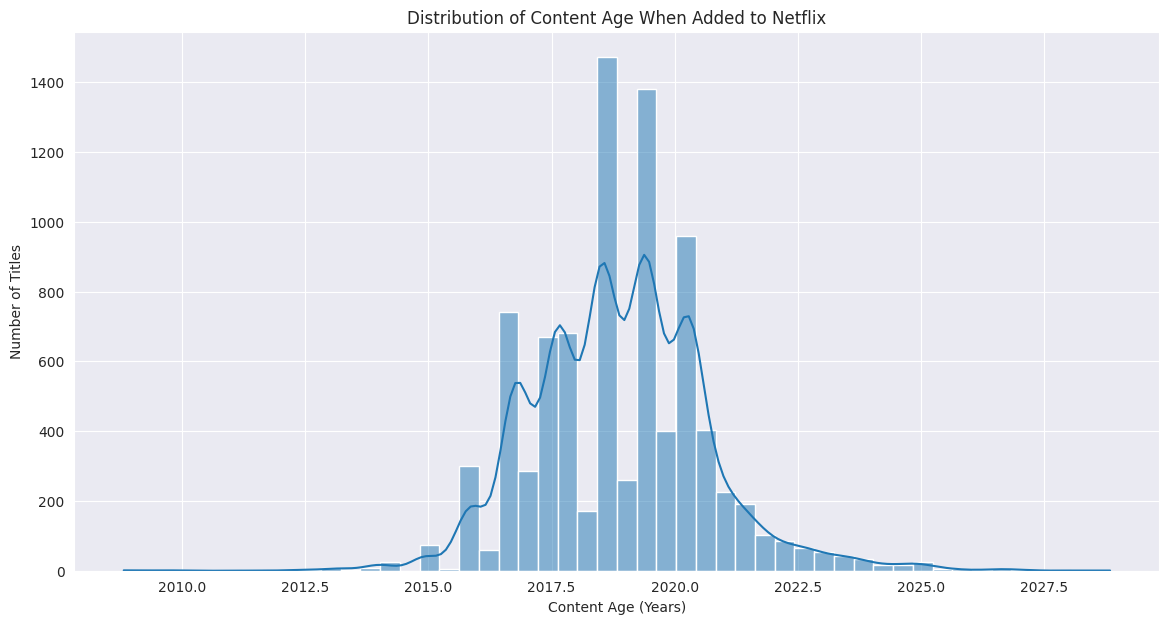

In [45]:
# Create the 'age_on_netflix' feature
netflix_df['age_on_netflix'] = netflix_df['year_added'] - netflix_df['release_year']

# Filter out any potential errors where added_year is before release_year
content_age = netflix_df[netflix_df['age_on_netflix'] >= 0]

plt.figure(figsize=(14, 7))
sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True)
plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

**Insight:** The large spike at `0` indicates that a significant amount of content is added in the same year it's released, which is characteristic of "Netflix Originals." However, there is a very long tail, showing that Netflix also heavily invests in acquiring licensed content that can be decades old, building a deep library of classic films and shows.

### Step 3: Deeper Multivariate Analysis

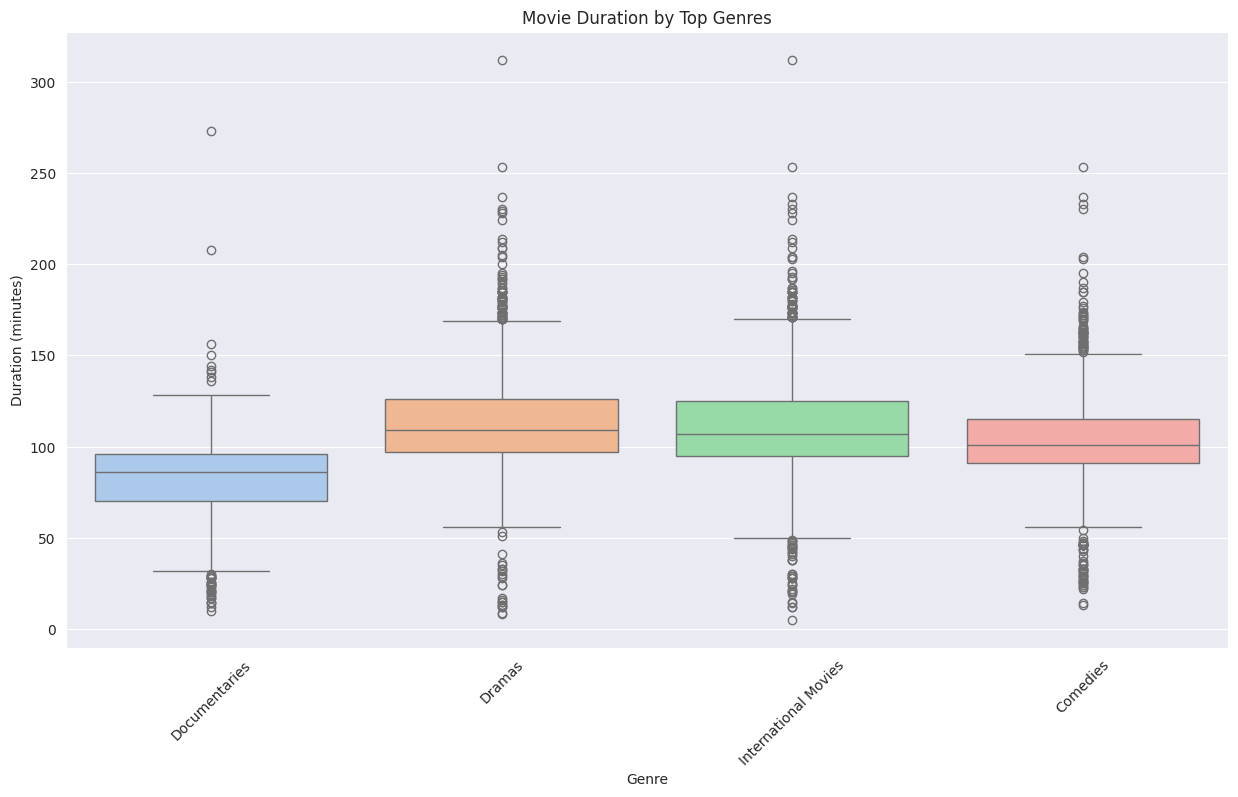

In [46]:
# Analyze movie duration across different top genres
top_genres = genres['genre'].value_counts().index[:5]
genres_movies = genres[(genres['type'] == 0) & (genres['genre'].isin(top_genres))].copy()
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(15, 8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min', palette='pastel', hue='genre', legend=False)
plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()

**Insight:** While the median duration for most top genres is similar (around 90-100 minutes), we can see some interesting variations. For example, Dramas tend to have a wider range of durations, with many longer films. International Movies also show a broad distribution, reflecting diverse filmmaking styles from around the world.

### Step 4: Word Cloud from Content Descriptions
As a final visual analysis, let's generate a word cloud from the `description` column to see what themes and words are most common in Netflix content.

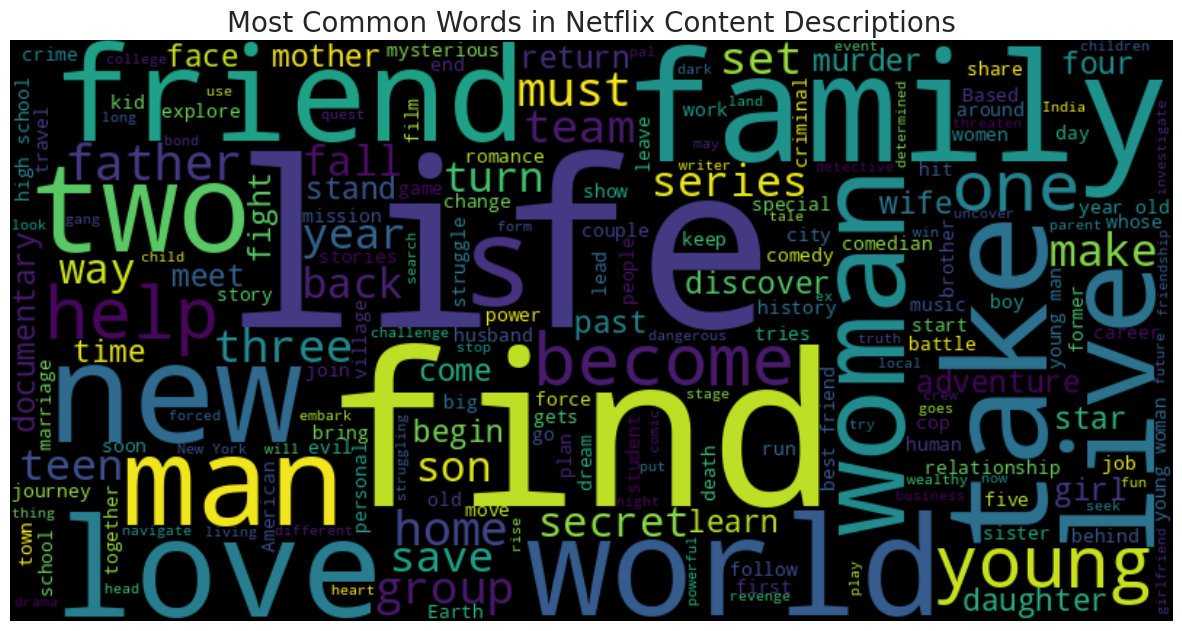

In [47]:
# Combine all descriptions into a single string
text = ' '.join(netflix_df['description'])

# Create and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

**Insight:** The word cloud highlights common themes and subjects. Words like "life," "family," "love," "young," "friends," and "world" are prominent, suggesting that much of the content revolves around human relationships and personal journeys. Action-oriented words like "find," "secret," and "new" also appear frequently.

### Step 5: One numerical comparison plot

In [48]:
numerical_cols = netflix_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = netflix_df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
for col in numerical_cols:
    print(f"- {col}")

print("\nCategorical Columns:")
for col in categorical_cols:
    print(f"- {col}")

Numerical Columns:
- type
- release_year
- duration_value
- duration_minutes
- duration_seasons
- maturity_level
- age_on_netflix

Categorical Columns:
- show_id
- title
- director
- cast
- country
- rating
- duration
- listed_in
- description


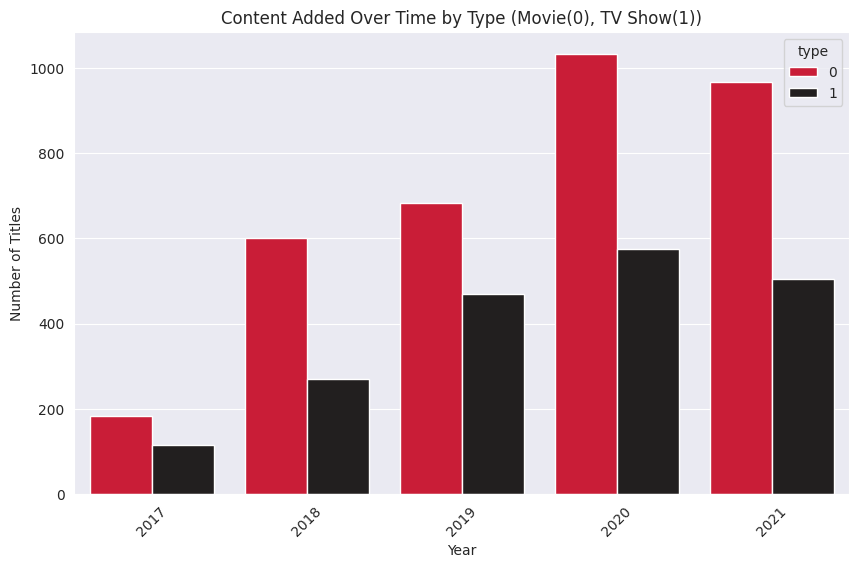

In [98]:
plt.figure(figsize=(10,6))

# Group by year_added and type, then count titles
content_counts = netflix_df.groupby(['year_added', 'type']).size().reset_index(name='count')

sns.barplot(
    data=content_counts,
    x='year_added',
    y='count',
    hue='type',
    palette=['#e60023', '#221f1f']
)

plt.title("Content Added Over Time by Type (Movie(0), TV Show(1))")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

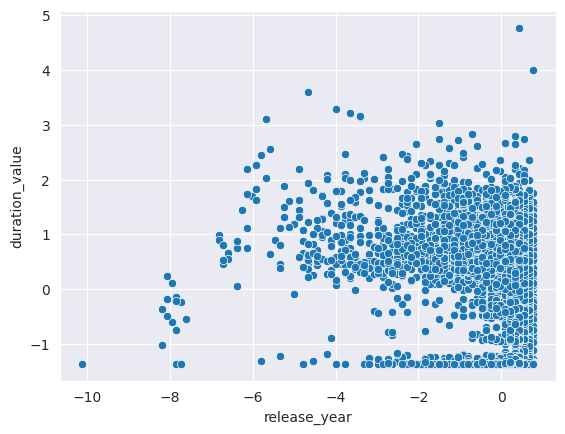

In [51]:
sns.scatterplot(x='release_year', y='duration_value', data=netflix_df)
plt.show()

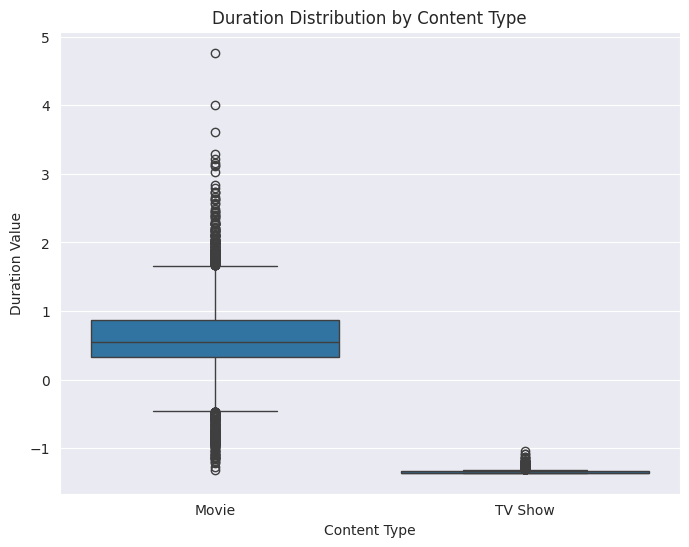

In [52]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=netflix_df,
    x='type',
    y='duration_value'
)

plt.xticks(
    ticks=[0,1],
    labels=['Movie', 'TV Show']
)

plt.title('Duration Distribution by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Duration Value')

plt.show()

Movies have a much higher median duration compared to TV shows. The interquartile range for movies is also wider, while TV shows are concentrated at lower duration values. This clear separation explains why duration is a strong feature for classification.

### Summary of Insights

This in-depth EDA of the Netflix dataset has revealed several key characteristics and strategies of the platform's content library.

**Key Findings:**
1. **Content Strategy:** Netflix's library is movie-heavy (~70%), and the platform aggressively added content between 2016-2019. Their strategy involves a mix of brand new originals (added the same year they are released) and a deep library of licensed older content.
2. **Global Dominance:** While the US is the top content producer, the platform is heavily international, with India being a massive contributor. This is reflected in the top genres ("International Movies") and most frequent actors.
3. **Target Audience:** The content library is skewed towards mature audiences, with `TV-MA` and `TV-14` being the most common ratings.
4. **Content Format & Genre:** Dramas and Comedies are universally popular genres. Most movies stick to a standard 90-120 minute runtime, while the vast majority of TV shows only last for a single season, suggesting a high-risk, high-reward approach to series production.
5. **Common Themes:** Descriptions of content frequently revolve around universal themes of life, family, love, and discovery.

**Limitations:** This dataset is a snapshot in time and lacks viewership data. Therefore, our analysis is of the *supply* of content, not its *demand* or popularity.

# PART 4: ML Readiness Check

## Subtask 1: Without preprocessing

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [54]:
netflix_odf = pd.read_csv('/content/netflix_titles.csv')
netflix_odf.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


**Without preprocessing:**

- No traditional machine learning model can be trained directly on the raw dataset because the features contain text, missing values, and inconsistent formats.
- Logistic Regression is sensitive to feature scale because it is an optimization-based algorithm that depends on gradient descent.
- Decision Tree can be used without feature scaling, but categorical text must still be encoded.

**Conclusion:** We cannot perform model training on raw data without data preprocessing.

## Subtask 2: With preprocessing

After preprocessing, categorical variables were converted into numerical representations and the numerical features were scaled to ensure uniformity. The machine learning model uses release_year and duration as input features to predict whether the content is a movie or a TV show.

`release_year` and `duration_value` as input features (X) and `type` as the target feature (y) from the `netflix_df`

In [80]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_minutes,duration_seasons,maturity_level,year_added,month_added,age_on_netflix
0,s1,0,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,0.659134,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0.395056,90.0,NaN,3,2021,9,2020.340866
1,s2,1,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,0.772449,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",-1.337515,NaN,2.0,0,2021,9,2020.227551


**Define dependant and independant features**

In [81]:
X = netflix_df[['release_year','duration_value']]
y = netflix_df['type']

**Split the data for training and testing**

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**Training Logistic Regression Algorithm**

In [83]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [84]:
acc_LR= accuracy_score(y_test, model.predict(X_test))
acc_LR

0.997155858930603

**Training Decision Tree Algorithm**

In [85]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(max_depth = 3)
model2.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [86]:
acc_DT = accuracy_score(y_test, model2.predict(X_test))
acc_DT

0.9988623435722411

Regardless of the algorithm employed, the chosen features are very successful for this classification task, as demonstrated by the nearly identical **99%** accuracies of the `Logistic Regression` and `Decision Tree` models.


**Model Evaluation**

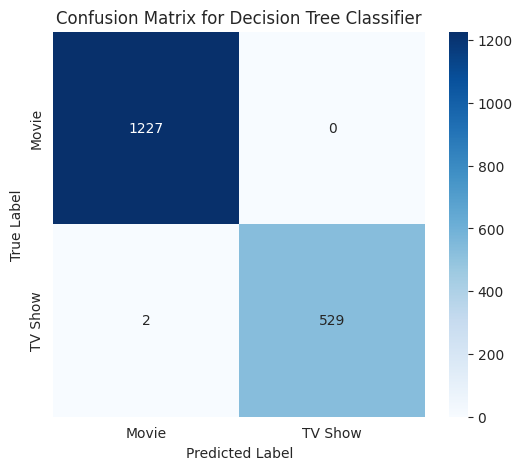

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_dt = model2.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Movie', 'TV Show'], yticklabels=['Movie', 'TV Show'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

In [88]:
# classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       531

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



With just **two misclassifications** out of **1758** samples, the confusion matrix demonstrates how well the Decision Tree model performs. Just two TV series were misclassified as films, while all films were appropriately categorized. With an accuracy of roughly **99.89%**, this shows that the model generalizes well for both classes and that the chosen features offer strong class separation.

# PART 5: ML Lifecycle Reflection

**Q1. Explain which ML lifecycle stages fail without preprocessing.**


Because machine learning models need clean, organized, and numerical input, data preprocessing is crucial. Several phases of the machine learning lifecycle are impacted in the absence of preprocessing.

Inconsistent formats, missing values, and inaccurate data types hinder accurate analysis during the data understanding stage. Because raw data is not in a machine-readable format, it is impossible to extract useful features during the feature engineering stage. Because most algorithms are unable to handle unscaled numerical features, missing values, or categorical text, the model training stage fails. Because the model learns from low-quality input data, this also produces unreliable results during the model evaluation stage.



---


**Q2. Give one concrete example from this assignment.**

The `duration` column in this dataset initially held text-based values like **"90 min"** and **"2 Seasons,"** which are not suitable for model training. The numerical value was extracted into a new feature (`duration_value`) following preprocessing. One of the most crucial elements for correctly identifying whether the content is a film or television program is this conversion, which transformed the data into a format suitable for machine learning.

# Thank You!